In [1]:
# Scripts imports
import source.processing as processing
import source.analyze as analyze

> Dir `data_imports` already exists.
> Dir `data_processed` already exists.
> Dir `lpa_input` already exists.
> Dir `lpa_results` already exists.


---
### `Substitution Survival` Analysis
## Part 1 - Preprocessing
In this part we will 
1. Import the raw data from the MySQL server
2. Preprocess the data into mutation dataframe
3. Create suitible input for the LPA algorithm

In [ ]:
### Preparing the data for the LPA analysis - Substitution Survival
# 1. Creating the LPA preprocessing object, defining the analysis metric.
lpa_preprocessing = processing.lpa_prep(metric = "substitution_survival")

# 2. Importing the data from the mysql server (if required).
lpa_preprocessing.import_tables()

# 2. Process the raw sql imports to the 
lpa_preprocessing.process_tables(metadata_columns="collection_time_point_relative,cell_subset",
                                metadata_rename="time_point,ab_target")

# 3. Removing every file (to free space) except the file required for the lpa document construction
#lpa_preprocessing.purge_data()

# 4. Creating the required document for the LPA analysis
#    Can load the input data as csv or as pd.DataFrame object - can modify column name and data as see fit
# Creating the required document for the LPA analysis
lpa_preprocessing.create_documents(document = "ab_target,time_point,subject_id",
                                    overwrite = False)

> Dir `data_imports` already exists.
> Dir `data_processed` already exists.
> Dir `lpa_input` already exists.
> Dir `lpa_results` already exists.
> Dir `data_imports\covid_vaccine_new-substitution_survival` already exists.
> Dir `data_processed\covid_vaccine_new-substitution_survival` already exists.
> Dir `lpa_input\covid_vaccine_new-substitution_survival` already exists.
> Dir `lpa_results\covid_vaccine_new-substitution_survival` already exists.
> Established connecntion to the covid_vaccine_new database.
> Connected to the MySQL server (covid_vaccine_new).
clones.csv:
> importing table `clones` to data_imports\covid_vaccine_new-substitution_survival\clones.csv.
> Query executed successfully: 

                                SELECT * FROM covid_vaccine_new.clones;
                                
clone_stats.csv:
> importing table `clone_stats` to data_imports\covid_vaccine_new-substitution_survival\clone_stats.csv.
> Query executed successfully: 

                                SE

c:\Users\Daniel\Desktop\Github\immunedb_lpa\source\processing.py:153: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1 baseline']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metadata_df.loc[metadata_df["sample_id"]==i,j] = metadata_og.loc[(metadata_og["sample_id"]==i)&(metadata_og["key"]==j),"value"].values
c:\Users\Daniel\Desktop\Github\immunedb_lpa\source\processing.py:153: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Non-Spike B']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metadata_df.loc[metadata_df["sample_id"]==i,j] = metadata_og.loc[(metadata_og["sample_id"]==i)&(metadata_og["key"]==j),"value"].values


> clones_merged dataframe created and saved, continuing....
> mut_df dataframe created and saved, continuing....
> Successfully created mutation dataframe (mut_df.csv)
> mut_df dataframe created and saved, continuing....
> Loaded processed metric dataframe.
> Created lpa input succseffuly


---
## Part 2 - LPA Analysis

In this part we will 
1. Use the `lpa_input.csv` that was created during part 1.
2. Create signaure dataframe.
3. Visulize the signatures via heatmap.
4. Perform PCA and visulize the results in scatterplot.

In [2]:
# Initiating the LPA algorithm object
lpa_mutsub = analyze.lpa_analysis(metric="substitution_survival")

> The following document havn't met the treshold (100):
                     document  frequency_in_document
18  Spike+ Mem B.1 baseline.6                     88
19  Spike+ Mem B.1 baseline.7                      3
24     Spike+ Mem B.2 weeks.7                     29
26     Spike+ Mem B.4 weeks.4                     63


c:\github\immunedb_lpa\source\lpa_algo.py:18: RuntimeWarning: divide by zero encountered in divide
  return (P - Q) * np.log2(np.where(P == 0, Q, P) / Q)


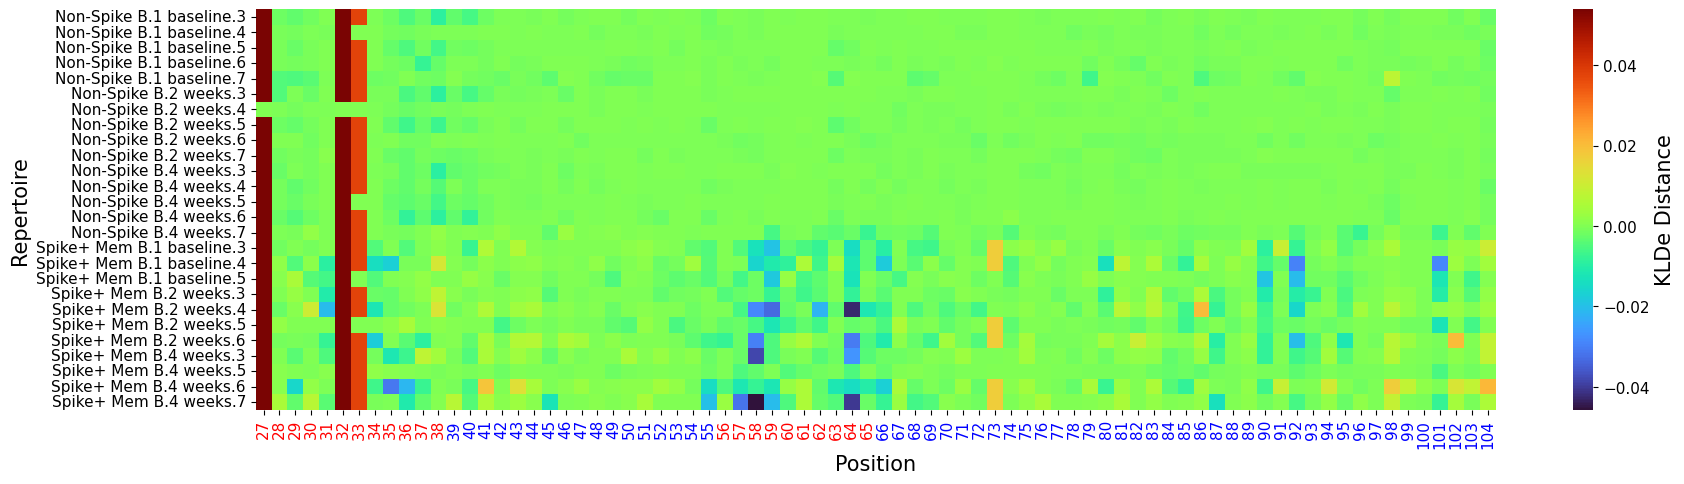

In [3]:
#Plotting heatmap of the domain KLDe distances
lpa_mutsub.heatmap()

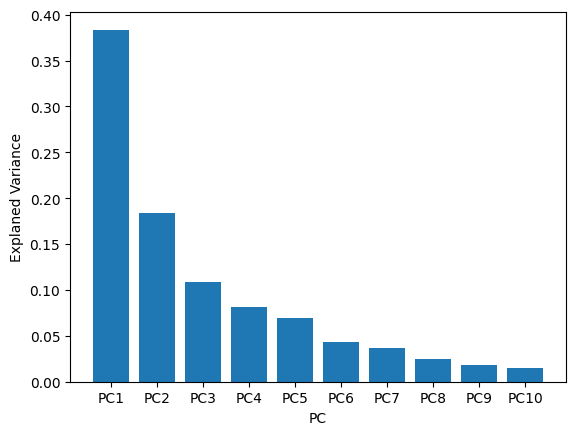

In [4]:
# Perform PCA and plot scatterplot
pca_mutsub = lpa_mutsub.pca()

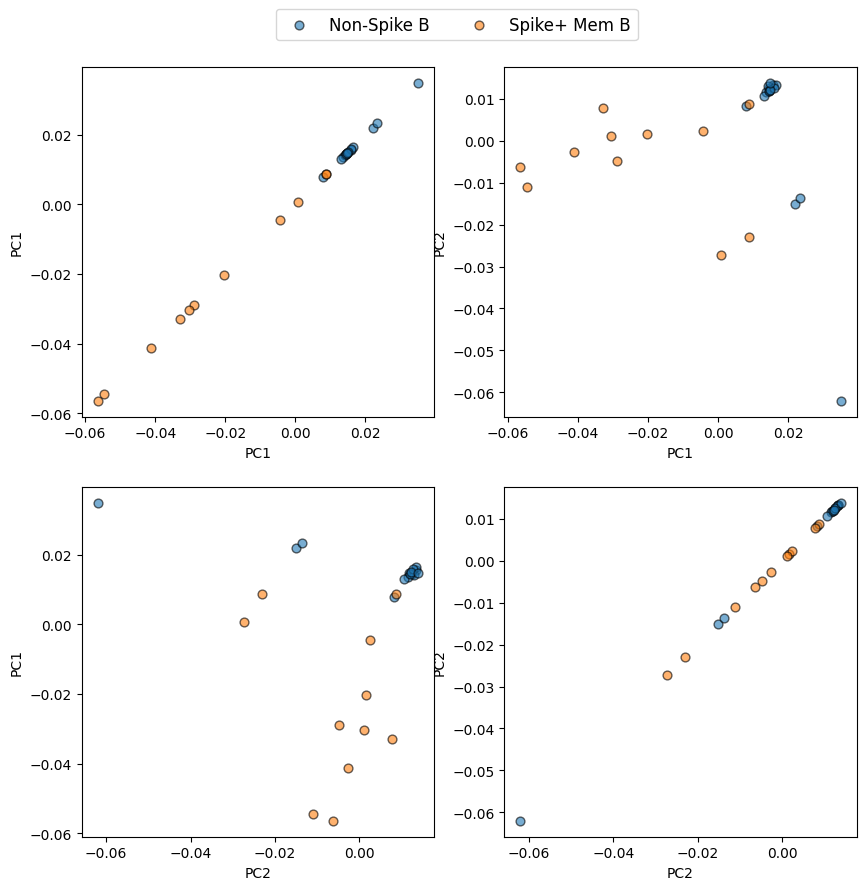

In [5]:
# Using scatter plot to visualize the PCA analysis
lpa_mutsub.pca_scatter(n_pcs=2, label_index=0)

---
### `Trimer Usage` Analysis
## Part 1 - Preprocessing
In this part we will 
1. Import the raw data from the MySQL server
2. Preprocess the data into mutation dataframe
3. Create suitible input for the LPA algorithm

In [7]:
### Preparing the data for the LPA analysis - Trimers Usage
# 1. Creating the LPA preprocessing object, defining the analysis metric.
lpa_preprocessing = processing.lpa_prep(metric = "trimers_usage")

# 2. Importing the data from the mysql server (if required).
lpa_preprocessing.import_tables()

# 2. Process the raw sql imports to the 
lpa_preprocessing.process_tables(metadata_columns="collection_time_point_relative,cell_subset",
                                 metadata_rename="time_point,ab_target")

# 3. Removing every file (to free space) except the file required for the lpa document construction
#lpa_preprocessing.purge_data()

# 4. Creating the required document for the LPA analysis
#    Can load the input data as csv or as pd.DataFrame object - can modify column name and data as see fit
# Creating the required document for the LPA analysis
lpa_preprocessing.create_documents(document = "ab_target,time_point,subject_id",
                                overwrite = False)

> Dir `data_imports\covid_vaccine_new-trimers_usage` already exists.
> Dir `data_processed\covid_vaccine_new-trimers_usage` already exists.
> Dir `lpa_input\covid_vaccine_new-trimers_usage` already exists.
> Dir `lpa_results\covid_vaccine_new-trimers_usage` already exists.
> Established connecntion to the covid_vaccine_new database.
> Connected to the MySQL server (covid_vaccine_new).
sequences.csv:
> raw table `sequences` already exists at data_imports\covid_vaccine_new-trimers_usage\sequences.csv. continuing.
sequence_collapse.csv:
> raw table `sequence_collapse` already exists at data_imports\covid_vaccine_new-trimers_usage\sequence_collapse.csv. continuing.
sample_metadata.csv:
> raw table `sample_metadata` already exists at data_imports\covid_vaccine_new-trimers_usage\sample_metadata.csv. continuing.
> MySQL connenction terminated.
imported tabled:['sample_metadata.csv' 'sequence_collapse.csv' 'sequences.csv'] from required talbed: ['sample_metadata.csv' 'sequence_collapse.csv' 's

100%|██████████| 30/30 [13:28<00:00, 26.97s/it]


> Trimers and unique clones data saved to 'trimers_output' folder.


---
## Part 2 - LPA Analysis

In this part we will 
1. Use the `lpa_input.csv` that was created during part 1.
2. Create signaure dataframe.
3. Visulize the signatures via heatmap.
4. Perform PCA and visulize the results in scatterplot.

In [8]:
# Initiating the LPA algorithm object
lpa_mutsub = analyze.lpa_analysis(metric="trimers_usage")

> The following document havn't met the treshold (100):
                  document  frequency_in_document
19  Spike+MemB.1baseline.7                      2
24     Spike+MemB.2weeks.7                     41
26     Spike+MemB.4weeks.4                     53


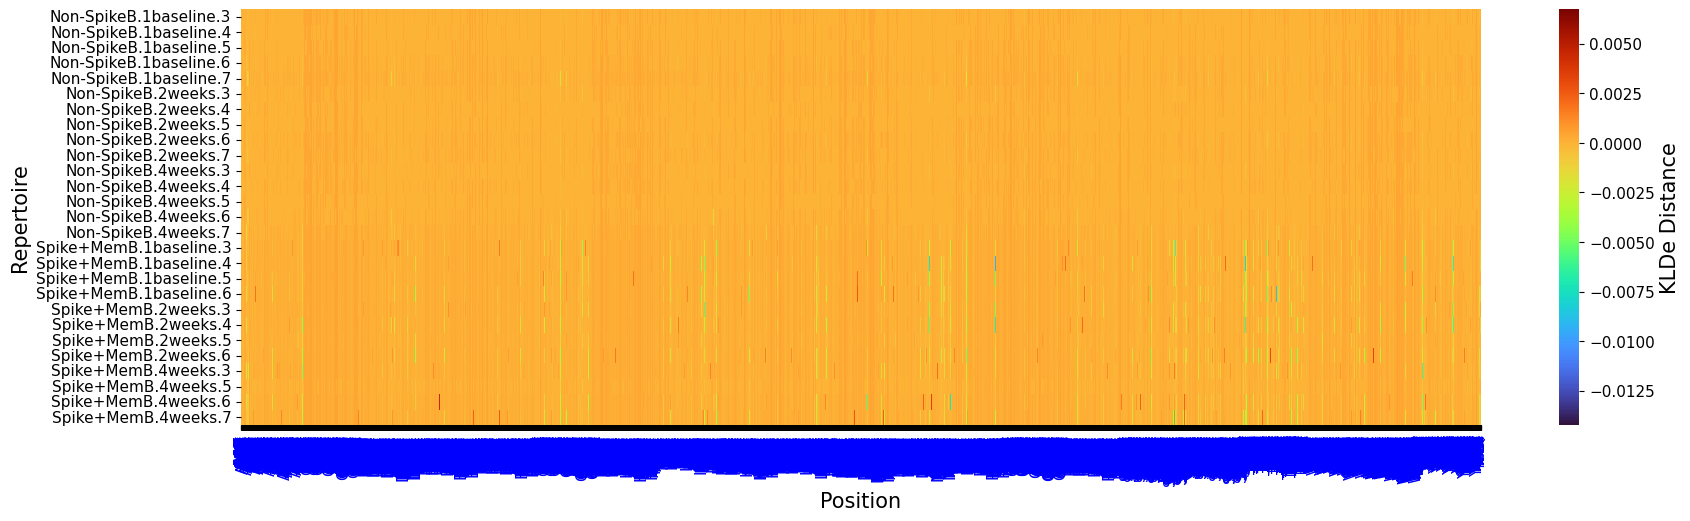

In [9]:
#Plotting heatmap of the domain KLDe distances
lpa_mutsub.heatmap()

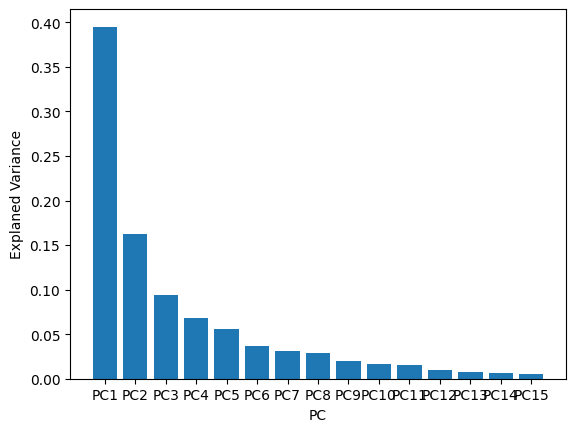

In [10]:
# Perform PCA and plot scatterplot
pca_mutsub = lpa_mutsub.pca()

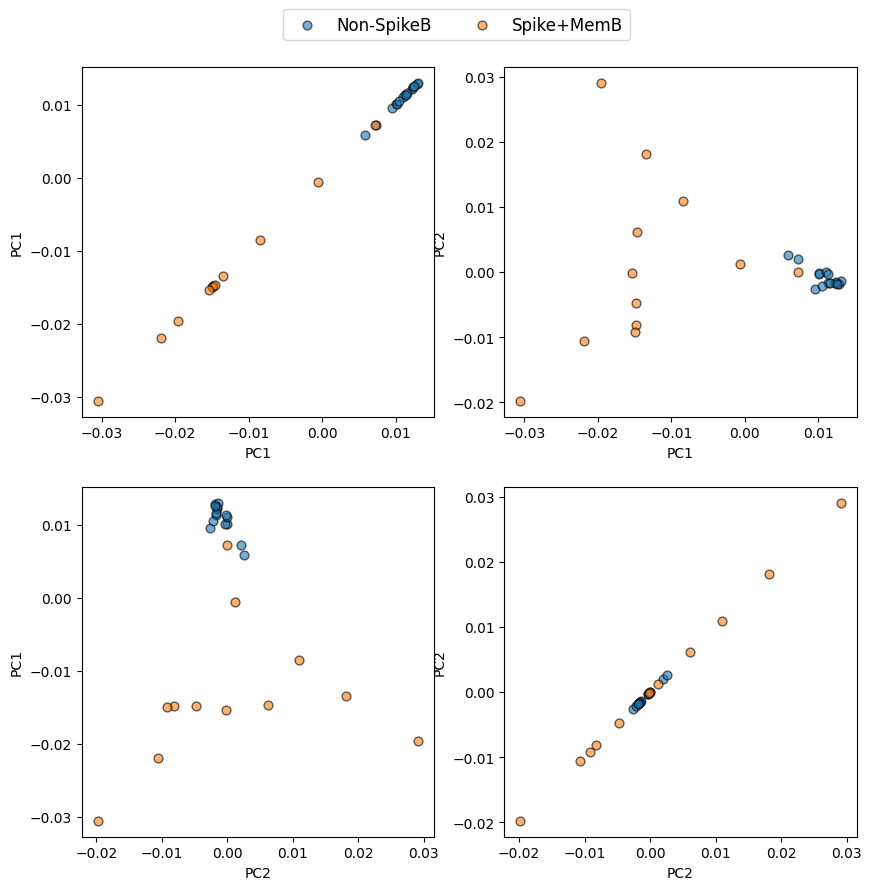

In [11]:
# Using scatter plot to visualize the PCA analysis
lpa_mutsub.pca_scatter(n_pcs=2, label_index=0)